In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess

# Check if required packages are installed, install them if missing
def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_package("pytorch-tabnet")
install_package("shap")
install_package("xgboost")
install_package("tensorflow")

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pytorch_tabnet.tab_model import TabNetClassifier
import shap

In [62]:
train = pd.read_csv("playground-series-s6e3/train.csv")
test = pd.read_csv("playground-series-s6e3/test.csv")


In [63]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [64]:
df = train

In [65]:
df.isnull().values.any()
# no imputing is needed

np.False_

In [66]:
# Clean categorical text safely (train + test common columns)
cat_cols_train = train.select_dtypes(include=["object"]).columns.tolist()
cat_cols_test = test.select_dtypes(include=["object"]).columns.tolist()
common_cat_cols = [c for c in cat_cols_train if c in cat_cols_test]

for col in common_cat_cols:
    train[col] = train[col].astype(str).str.strip()
    test[col] = test[col].astype(str).str.strip()



In [67]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [68]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [69]:
pd.get_dummies(df["gender"])

,Female,Male
0,False,True
1,False,True
2,False,True
3,True,False
4,True,False
...,...,...
594189,False,True
594190,True,False
594191,True,False
594192,True,False


In [70]:
df.describe(include=['O'])

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


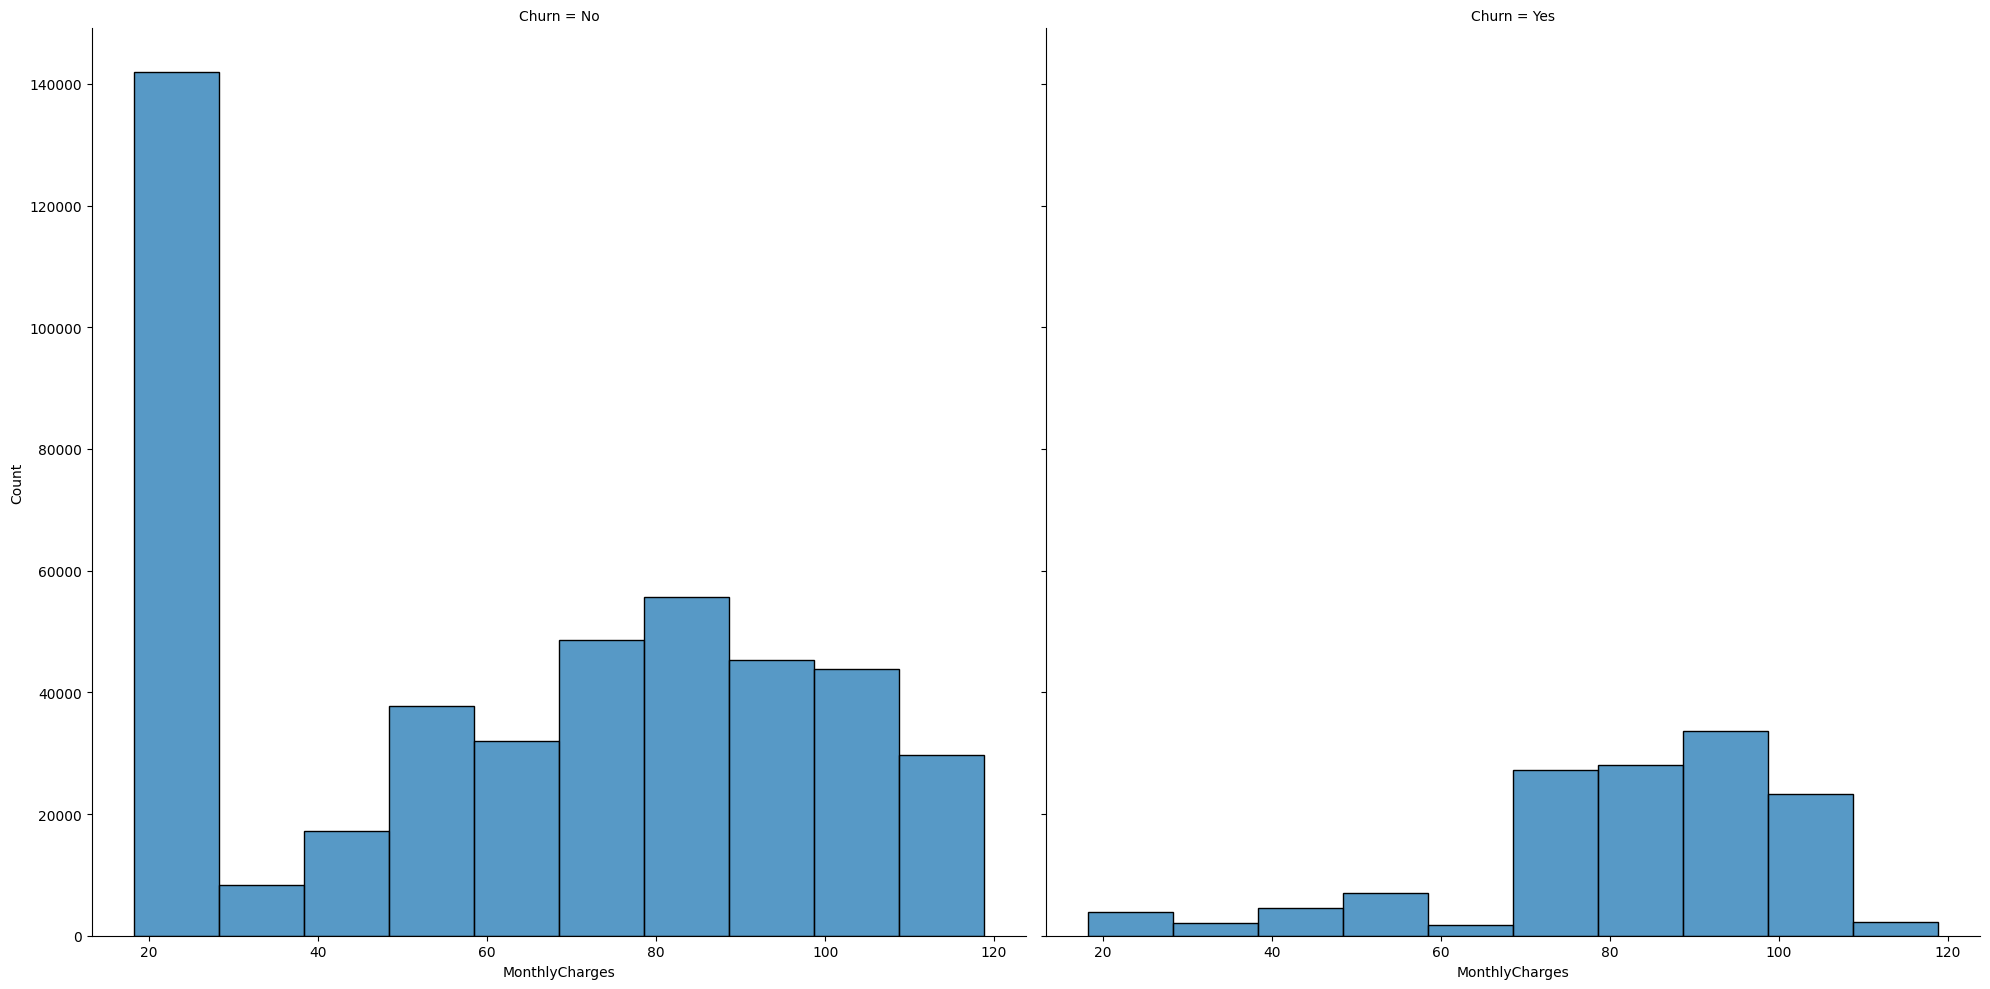

In [71]:
sns.displot(df, x='MonthlyCharges',col='Churn',binwidth = 10,height=10)
plt.show()

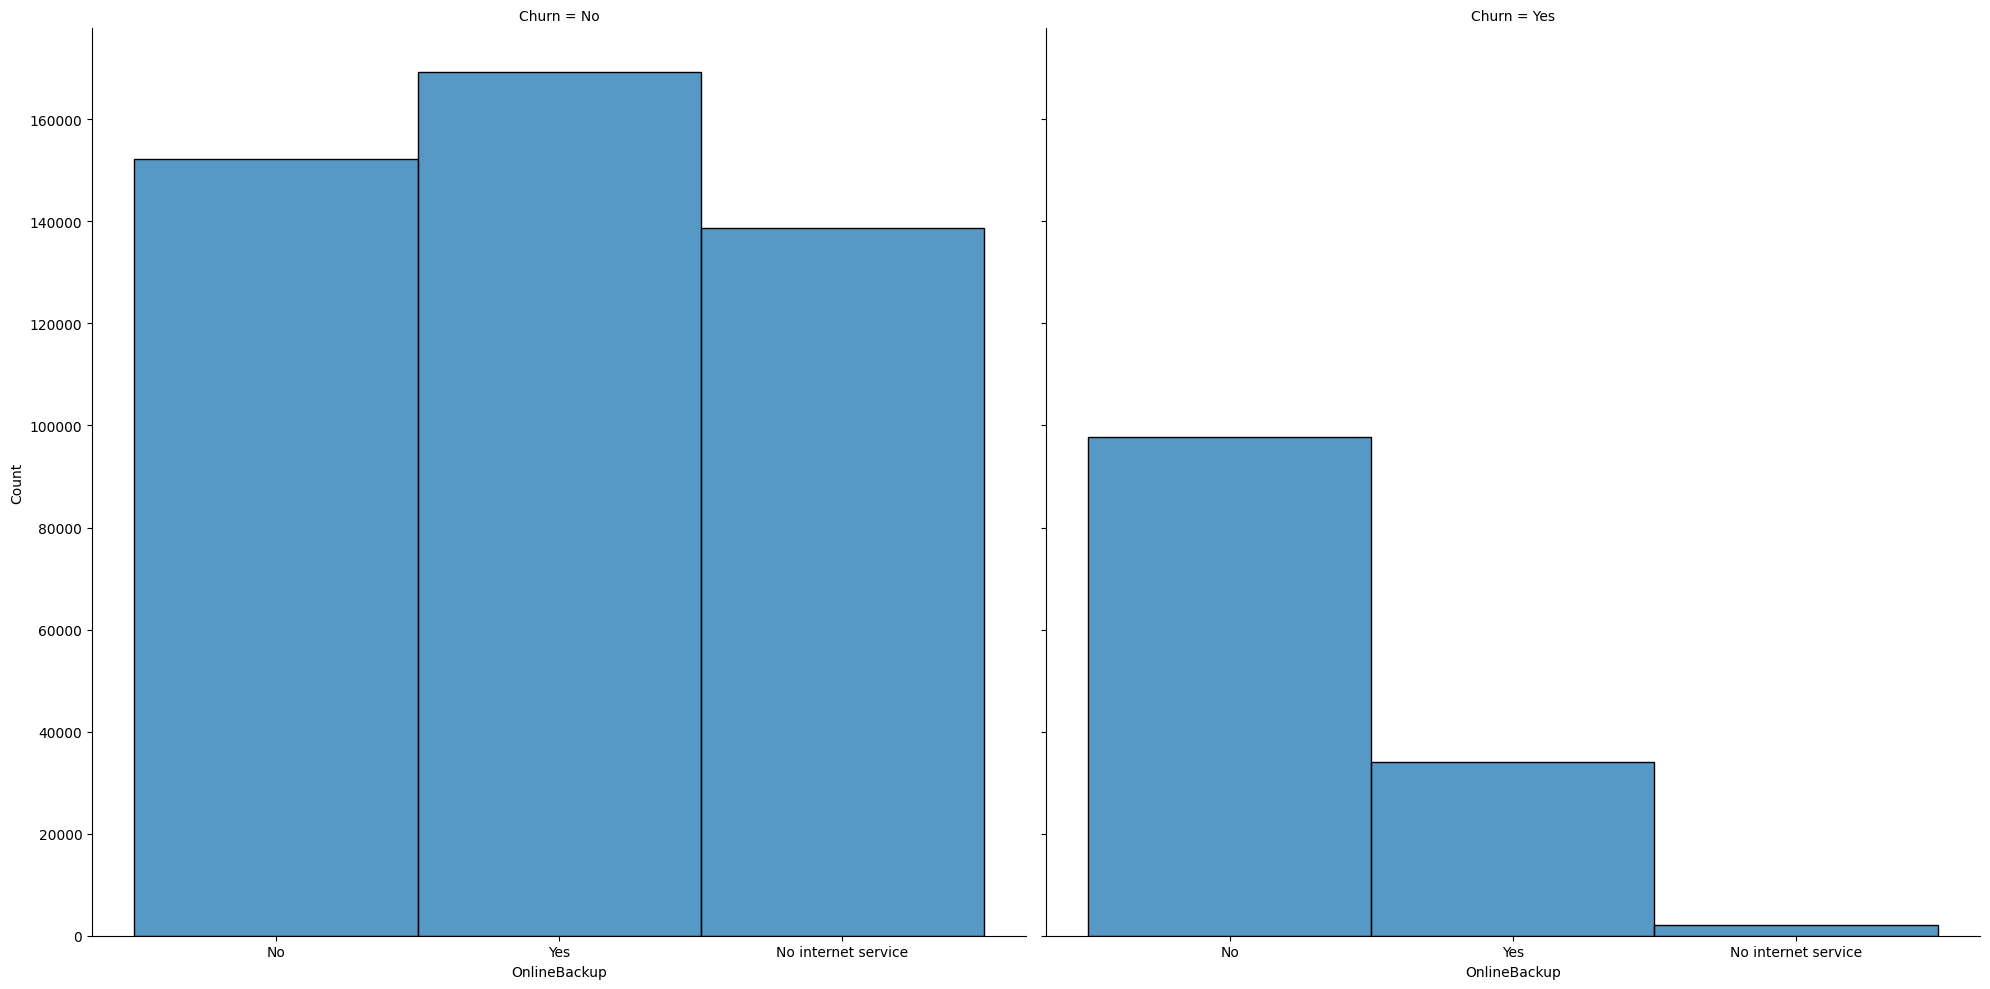

In [72]:
sns.displot(df, x='OnlineBackup',col='Churn',binwidth = 10,height=10)
plt.show()

In [73]:
from sklearn.preprocessing import OrdinalEncoder

# Binary categorical features -> one numeric column (0/1-like)
binary_pipeline = Pipeline(steps=[
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Multi-category features -> one-hot, drop first level to avoid redundancy
ohe_pipeline = Pipeline(steps=[
    ("one-hot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

In [74]:
df["tenure"].describe()

count    594194.000000
mean         36.577258
std          25.061922
min           1.000000
25%          12.000000
50%          35.000000
75%          62.000000
max          72.000000
Name: tenure, dtype: float64

In [75]:
X = train.drop(columns=[df.columns[-1],df.columns[0]])

In [76]:
df.head()
from sklearn.compose import ColumnTransformer

# Detect categorical columns from features
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Split categories into binary vs multi-class to prevent redundant one-hot columns
binary_cat_cols = [c for c in cat_cols if X[c].nunique(dropna=False) <= 2]
multi_cat_cols = [c for c in cat_cols if X[c].nunique(dropna=False) > 2]
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Binary categorical columns:", binary_cat_cols)
print("Multi-class categorical columns:", multi_cat_cols)

col_trans = ColumnTransformer(
    transformers=[
        ("binary_cat", binary_pipeline, binary_cat_cols),
        ("multi_cat_ohe", ohe_pipeline, multi_cat_cols),
        ("num_scaler", StandardScaler(), num_cols),
    ],
    n_jobs=-1,
)

Binary categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [77]:
test_ids = test[df.columns[0]]
test = test.drop(columns=df.columns[0])
y = df[df.columns[-1]]
y = y.map({'No':0,'Yes':1})
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2,random_state=42)

In [78]:
col_trans.fit(X_train)
X_train_trans = col_trans.transform(X_train)
X_val_trans = col_trans.transform(X_val)
test_trans = col_trans.transform(test)

In [79]:
X_train_trans.shape[1]

30

In [80]:
test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [82]:

tabnet = TabNetClassifier()

tabnet.fit(
        X_train_trans,
        y_train,
        eval_set=[(X_val_trans, y_val)],
        max_epochs=50,
        
    )

/home/berimbolo/agh/6sem/ml/.venv/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.3338  | val_0_auc: 0.90914 |  0:00:13s
epoch 1  | loss: 0.31198 | val_0_auc: 0.91123 |  0:00:28s
epoch 2  | loss: 0.30999 | val_0_auc: 0.91163 |  0:00:41s
epoch 3  | loss: 0.30932 | val_0_auc: 0.91196 |  0:00:56s
epoch 4  | loss: 0.30844 | val_0_auc: 0.91223 |  0:01:08s
epoch 5  | loss: 0.30768 | val_0_auc: 0.91274 |  0:01:22s
epoch 6  | loss: 0.30778 | val_0_auc: 0.91246 |  0:01:37s
epoch 7  | loss: 0.30734 | val_0_auc: 0.91286 |  0:01:53s
epoch 8  | loss: 0.30678 | val_0_auc: 0.91185 |  0:02:12s
epoch 9  | loss: 0.3073  | val_0_auc: 0.91226 |  0:02:28s
epoch 10 | loss: 0.30691 | val_0_auc: 0.91217 |  0:02:45s
epoch 11 | loss: 0.3068  | val_0_auc: 0.91151 |  0:03:04s
epoch 12 | loss: 0.30679 | val_0_auc: 0.91341 |  0:03:20s
epoch 13 | loss: 0.30617 | val_0_auc: 0.9131  |  0:03:40s
epoch 14 | loss: 0.30594 | val_0_auc: 0.90943 |  0:03:57s
epoch 15 | loss: 0.30627 | val_0_auc: 0.91331 |  0:04:19s
epoch 16 | loss: 0.30561 | val_0_auc: 0.9123  |  0:04:33s
epoch 17 | los

/home/berimbolo/agh/6sem/ml/.venv/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [83]:
# Predictions for TabNet (safe even if run independently)
if "results" not in globals():
    results = {}
if "y_prob_dict" not in globals():
    y_prob_dict = {}

X_eval_tabnet = X_val_trans
y_eval_tabnet = y_val

y_pred_tabnet = tabnet.predict(X_eval_tabnet)
y_prob_tabnet = tabnet.predict_proba(X_eval_tabnet)[:, 1]

y_prob_dict["TabNet"] = y_prob_tabnet
results["TabNet"] = {
    "Accuracy": accuracy_score(y_eval_tabnet, y_pred_tabnet),
    "Precision": precision_score(y_eval_tabnet, y_pred_tabnet, zero_division=0),
    "Recall": recall_score(y_eval_tabnet, y_pred_tabnet, zero_division=0),
    "F1 Score": f1_score(y_eval_tabnet, y_pred_tabnet, zero_division=0),
    "ROC-AUC": roc_auc_score(y_eval_tabnet, y_prob_tabnet),
}

print("TabNet metrics added to results.")

TabNet metrics added to results.


In [ ]:

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=10,
        random_state=42,
    ),
    "ANN": Sequential([
        Dense(64, activation="relu", input_shape=(X_train_trans.shape[1],)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]),
    "DNN": Sequential([
        Dense(128, activation="relu", input_shape=(X_train_trans.shape[1],)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]),
}

# 2) Training callbacks for neural networks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=1e-4,
    start_from_epoch=5,
    restore_best_weights=True,
    mode="min",
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)


def build_dnn(hidden_units, dropout_rates, input_dim):
    """Build a configurable feed-forward network."""
    model = Sequential()
    model.add(Dense(hidden_units[0], activation="relu", input_shape=(input_dim,)))

    for i, units in enumerate(hidden_units[1:]):
        model.add(Dense(units, activation="relu"))
        if i < len(dropout_rates) and dropout_rates[i] > 0:
            model.add(Dropout(dropout_rates[i]))

    model.add(Dense(1, activation="sigmoid"))
    return model


def build_dnn_with_input_bypass(hidden_units, dropout_rates, input_dim):
    """Build a DNN that concatenates raw input before the final hidden block."""
    inputs = Input(shape=(input_dim,))
    x = inputs

    for i, units in enumerate(hidden_units[:-1]):
        x = Dense(units, activation="relu")(x)
        if i < len(dropout_rates) and dropout_rates[i] > 0:
            x = Dropout(dropout_rates[i])(x)

    x = Concatenate()([x, inputs])
    x = Dense(hidden_units[-1], activation="relu")(x)
    x = Dense(32, activation="sigmoid")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    return Model(inputs=inputs, outputs=outputs)


# 3) Add extra DNN variants
models["DNN2"] = build_dnn(
    hidden_units=[256, 128, 64, 32],
    dropout_rates=[0.3, 0.3, 0.0],
    input_dim=X_train_trans.shape[1],
)

models["DNN3"] = build_dnn(
    hidden_units=[512, 256, 128, 32],
    dropout_rates=[0.4, 0.3, 0.2],
    input_dim=X_train_trans.shape[1],
)

models["DNN2_BYPASS"] = build_dnn_with_input_bypass(
    hidden_units=[256, 128, 64, 32],
    dropout_rates=[0.5, 0.3, 0.2],
    input_dim=X_train_trans.shape[1],
)


# 4) Train neural models in one loop
def train_neural_models(models_dict, X_train_data, y_train_data, X_val_data, y_val_data):
    nn_names = ["ANN", "DNN", "DNN2", "DNN3", "DNN2_BYPASS"]
    for model_name in nn_names:
        models_dict[model_name].compile(
            optimizer=Adam(learning_rate=0.001),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )
        models_dict[model_name].fit(
            X_train_data,
            y_train_data,
            validation_data=(X_val_data, y_val_data),
            epochs=50,
            batch_size=64,
            callbacks=[early_stopping, reduce_lr],
            verbose=0,
        )


def evaluate_models(models_dict, X_train_data, y_train_data, X_eval_data, y_eval_data):
    nn_names = ["ANN", "DNN", "DNN2", "DNN3", "DNN2_BYPASS"]
    local_results = {}
    local_y_prob_dict = {}

    for name, model in models_dict.items():
        if name in nn_names:
            y_prob = model.predict(X_eval_data, verbose=0).flatten()
        else:
            print(f"Training {name}...")
            model.fit(X_train_data, y_train_data)
            y_prob = model.predict_proba(X_eval_data)[:, 1] if hasattr(model, "predict_proba") else None

        if y_prob is not None:
            y_pred = (y_prob > 0.5).astype(int)
        else:
            y_pred = model.predict(X_eval_data)

        local_y_prob_dict[name] = y_prob
        local_results[name] = {
            "Accuracy": accuracy_score(y_eval_data, y_pred),
            "Precision": precision_score(y_eval_data, y_pred, zero_division=0),
            "Recall": recall_score(y_eval_data, y_pred, zero_division=0),
            "F1 Score": f1_score(y_eval_data, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_eval_data, y_prob) if (y_prob is not None and len(np.unique(y_eval_data)) > 1) else None,
        }

    return local_results, local_y_prob_dict


# 5) Run training + evaluation on validation split as the comparison set
X_test = X_val_trans
y_test = y_val
X_train = X_train_trans

train_neural_models(models, X_train, y_train, X_test, y_test)
results, y_prob_dict = evaluate_models(models, X_train, y_train, X_test, y_test)

print("Structured benchmark finished. Models evaluated:", list(results.keys()))

/home/berimbolo/agh/6sem/ml/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774898375.393469    4381 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774898375.410086    4381 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 20.

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 12: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 6.

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00

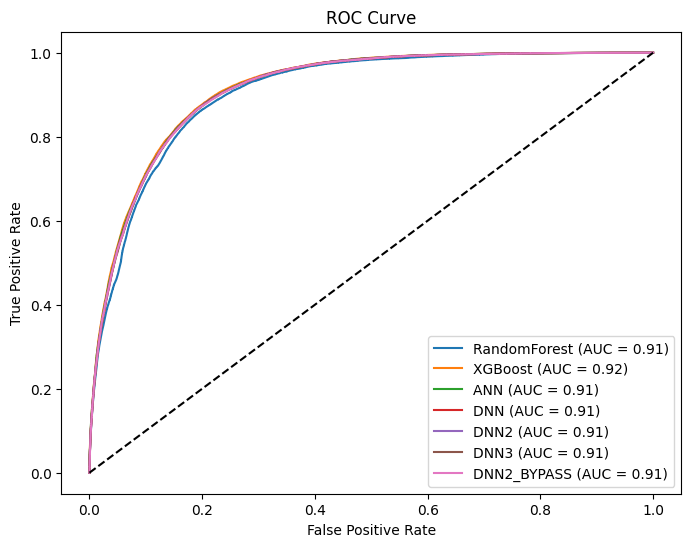

In [85]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plotted = False  # To check if at least one valid plot exists

for name, y_prob in y_prob_dict.items():
    if y_prob is not None and len(y_prob) > 0:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")
        plotted = True

if plotted:
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
else:
    print("No valid probability predictions found. Ensure models support `predict_proba()`.")

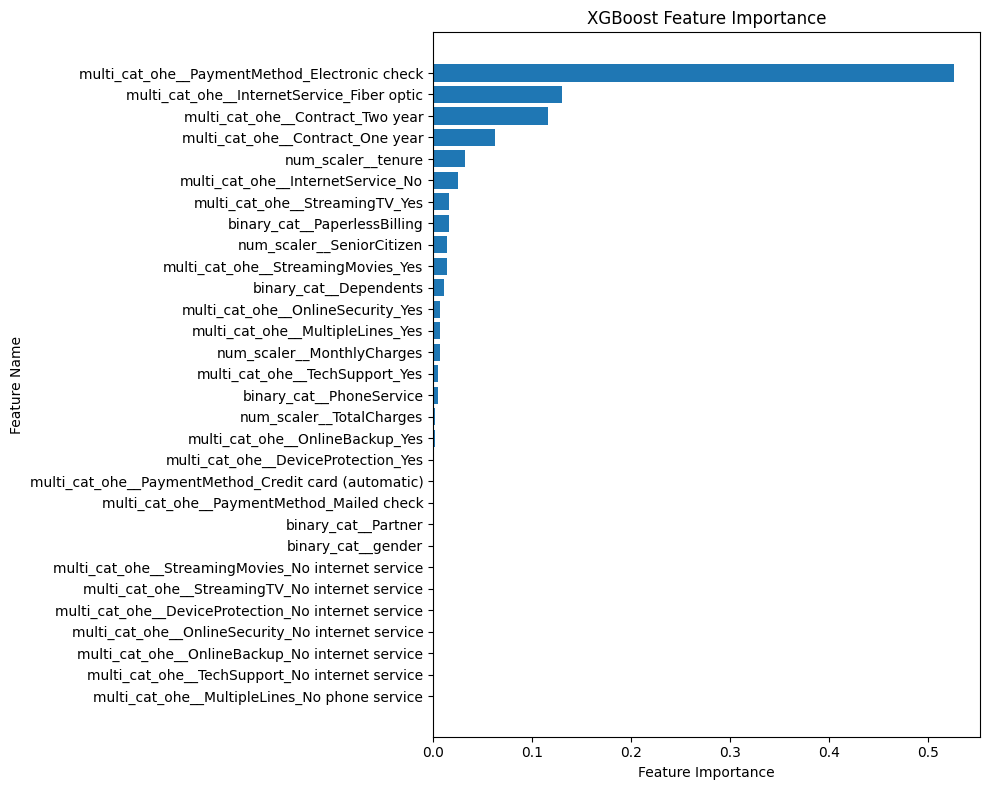

In [86]:
# Display feature importance for XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_trans, y_train)

feature_names = col_trans.get_feature_names_out()
importances = xgb_model.feature_importances_

# Plot top-k features for readability
top_k = min(30, len(importances))
top_idx = np.argsort(importances)[-top_k:]

plt.figure(figsize=(10, 8))
plt.barh(np.array(feature_names)[top_idx], importances[top_idx])
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

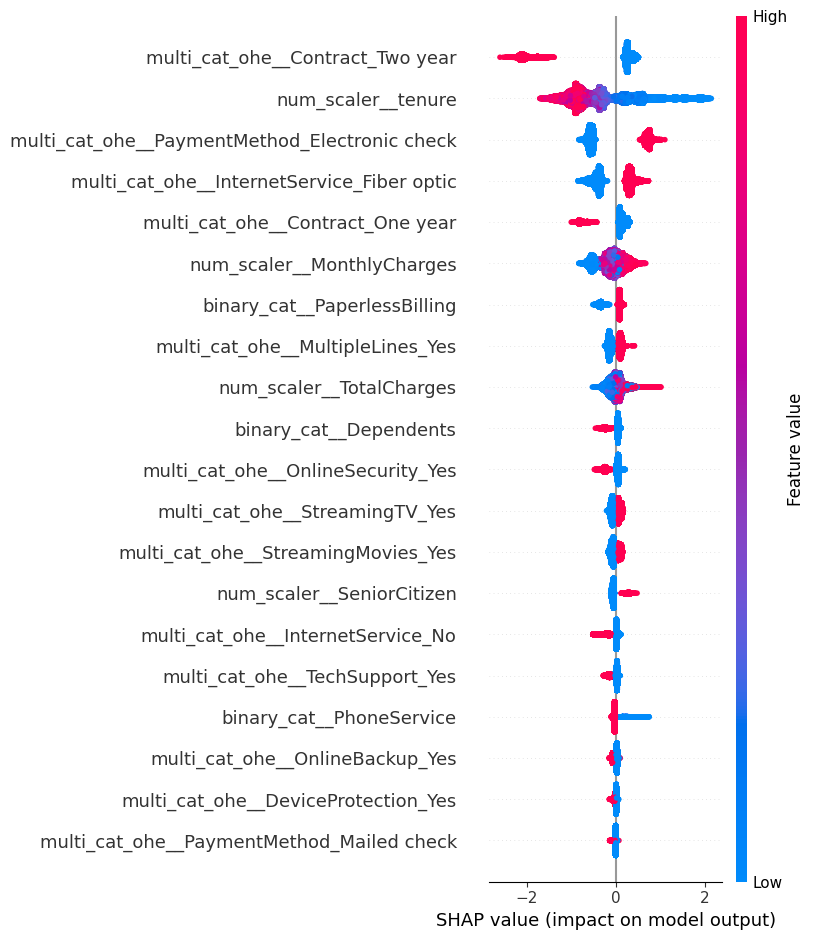

In [87]:
# SHAP Explainability
xgb_shap = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_shap.fit(X_train_trans, y_train)

explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_val_trans)

# Use transformed feature names for consistent interpretation
feature_names = col_trans.get_feature_names_out()
shap.summary_plot(shap_values, X_val_trans, feature_names=feature_names)

In [88]:
# Display results as a DataFrame
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:\n")
print(results_df)

Model Performance Comparison:

              Accuracy  Precision    Recall  F1 Score   ROC-AUC
RandomForest  0.846986   0.725276  0.521744  0.606900  0.906150
XGBoost       0.733261   0.457350  0.955583  0.618622  0.915136
ANN           0.858674   0.705559  0.644848  0.673839  0.913501
DNN           0.858481   0.718331  0.616711  0.663653  0.912888
DNN2          0.858153   0.713339  0.624331  0.665874  0.912771
DNN3          0.858161   0.694910  0.665775  0.680030  0.912888
DNN2_BYPASS   0.856663   0.735134  0.573483  0.644325  0.912683


In [ ]:
#example submission for kaggle competition
pred = models["DNN3"].predict(test_trans)
pred = (pred>0.5).astype(int)
pred = pd.DataFrame(pred, columns=['Churn'])
pred = pd.concat([test_ids, pred], axis=1)
pred.to_csv("submission.csv",index=False)

7958/7958 ━━━━━━━━━━━━━━━━━━━━ 4s 454us/step


In [ ]:
def build_and_train_model(neurons=32, layers=2, activation='relu', dropout_rate=0.3, optimizer='adam',
                          learning_rate=0.001, batch_size=16, regularization=None, batch_norm=False):
    model = Sequential()
    
  
    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],),
                    kernel_regularizer=regularization))

    if batch_norm:
        model.add(BatchNormalization())

    model.add(Dropout(dropout_rate))

    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation, kernel_regularizer=regularization))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    # Output Layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile Model
    if optimizer == "adam":
        optimizer = keras.optimizers.Adam(learning_rate)
    elif optimizer == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Train Model
    history = model.fit(X_train, y_train, epochs=50, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)

    # Evaluate Performance
    val_acc = max(history.history['val_accuracy'])
    return model, val_acc, history

## Hyperparameter Search with Optuna


In [ ]:
install_package("optuna")

import optuna
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping


np.random.seed(42)
tf.random.set_seed(42)


SEARCH_SPACE = {
    "neurons": [16, 32, 64, 128, 256, 512],
    "layers": [1, 2, 3, 4, 5],
    "activation": ["relu", "tanh", "sigmoid", "LeakyReLU", "elu"],
    "dropout_rate": [0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "optimizer": ["adam", "rmsprop", "sgd"],
    "learning_rate": [0.001, 0.01, 0.1],
    "batch_size": [8, 16, 32, 64, 128],
    "batch_norm": [False, True],
}

REG_CANDIDATES = [
    ("none", None),
    ("l1_0.0001", regularizers.l1(0.0001)),
    ("l1_0.001", regularizers.l1(0.001)),
    ("l1_0.01", regularizers.l1(0.01)),
    ("l1_0.1", regularizers.l1(0.1)),
    ("l2_0.0001", regularizers.l2(0.0001)),
    ("l2_0.001", regularizers.l2(0.001)),
    ("l2_0.01", regularizers.l2(0.01)),
    ("l2_0.1", regularizers.l2(0.1)),
    ("l1l2_0.0001", regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    ("l1l2_0.001", regularizers.l1_l2(l1=0.001, l2=0.001)),
    ("l1l2_0.01", regularizers.l1_l2(l1=0.01, l2=0.01)),
    ("l1l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.1)),
    ("l1_0.1_l2_0.01", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.1_l2_0.001", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.1_l2_0.0001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
    ("l1_0.01_l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.01_l2_0.001", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.01_l2_0.0001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
    ("l1_0.001_l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.001_l2_0.01", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.001_l2_0.0001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
    ("l1_0.0001_l2_0.1", regularizers.l1_l2(l1=0.1, l2=0.01)),
    ("l1_0.0001_l2_0.01", regularizers.l1_l2(l1=0.1, l2=0.001)),
    ("l1_0.0001_l2_0.001", regularizers.l1_l2(l1=0.1, l2=0.0001)),
]
REG_MAP = {name: reg for name, reg in REG_CANDIDATES}


def build_optuna_model(input_dim, neurons, layers, activation, dropout_rate, reg_obj, batch_norm):
    model = Sequential()

    if activation == "LeakyReLU":
        model.add(Dense(neurons, input_shape=(input_dim,), kernel_regularizer=reg_obj))
        model.add(LeakyReLU())
    else:
        model.add(Dense(neurons, activation=activation, input_shape=(input_dim,), kernel_regularizer=reg_obj))

    if batch_norm:
        model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(layers - 1):
        if activation == "LeakyReLU":
            model.add(Dense(neurons, kernel_regularizer=reg_obj))
            model.add(LeakyReLU())
        else:
            model.add(Dense(neurons, activation=activation, kernel_regularizer=reg_obj))

        if batch_norm:
            model.add(BatchNormalization())
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))
    return model


def make_optimizer(name, lr):
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=lr)
    if name == "rmsprop":
        return tf.keras.optimizers.RMSprop(learning_rate=lr)
    return tf.keras.optimizers.SGD(learning_rate=lr)


class KerasOptunaPruningCallback(tf.keras.callbacks.Callback):
    """Reports validation metric to Optuna and prunes unpromising trials."""

    def __init__(self, trial, monitor="val_auc"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_score = logs.get(self.monitor)
        if current_score is None:
            return
        self.trial.report(float(current_score), step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned(f"Trial pruned at epoch {epoch} with {self.monitor}={current_score:.5f}")


def objective(trial):
    params = {
        "neurons": trial.suggest_categorical("neurons", SEARCH_SPACE["neurons"]),
        "layers": trial.suggest_categorical("layers", SEARCH_SPACE["layers"]),
        "activation": trial.suggest_categorical("activation", SEARCH_SPACE["activation"]),
        "dropout_rate": trial.suggest_categorical("dropout_rate", SEARCH_SPACE["dropout_rate"]),
        "optimizer": trial.suggest_categorical("optimizer", SEARCH_SPACE["optimizer"]),
        "learning_rate": trial.suggest_categorical("learning_rate", SEARCH_SPACE["learning_rate"]),
        "batch_size": trial.suggest_categorical("batch_size", SEARCH_SPACE["batch_size"]),
        "batch_norm": trial.suggest_categorical("batch_norm", SEARCH_SPACE["batch_norm"]),
        "regularization": trial.suggest_categorical("regularization", list(REG_MAP.keys())),
    }

    model = build_optuna_model(
        input_dim=X_train_trans.shape[1],
        neurons=params["neurons"],
        layers=params["layers"],
        activation=params["activation"],
        dropout_rate=params["dropout_rate"],
        reg_obj=REG_MAP[params["regularization"]],
        batch_norm=params["batch_norm"],
    )

    model.compile(
        optimizer=make_optimizer(params["optimizer"], params["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )

    callbacks = [
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            restore_best_weights=True,
            verbose=0,
        ),
        KerasOptunaPruningCallback(trial, monitor="val_auc"),
    ]

    history = model.fit(
        X_train_trans,
        y_train,
        validation_data=(X_val_trans, y_val),
        epochs=30,
        batch_size=params["batch_size"],
        verbose=0,
        callbacks=callbacks,
    )

    return max(history.history["val_auc"])


sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=5,
    interval_steps=1,
)

study = optuna.create_study(
    direction="maximize",
    study_name="churn_nn_optuna",
    sampler=sampler,
    pruner=pruner,
)

study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\nBest validation AUC:", study.best_value)
print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
complete_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print(f"Pruned trials: {len(pruned_trials)} | Complete trials: {len(complete_trials)}")

best_params_optuna = study.best_params

Installing optuna...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 4.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 613.9/613.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.3 MB/s eta 0:00:00


[I 2026-03-30 21:32:55,769] A new study created in memory with name: churn_nn_optuna
  0%|          | 0/40 [00:00<?, ?it/s]/home/berimbolo/agh/6sem/ml/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
Best trial: 0. Best value: 0.5:   2%|▎         | 1/40 [00:25<16:22, 25.18s/it]

[I 2026-03-30 21:33:20,949] Trial 0 finished with value: 0.5 and parameters: {'neurons': 8, 'layers': 4, 'activation': 'elu', 'dropout_rate': 0.2, 'optimizer': 'rmsprop', 'learning_rate': 0.01, 'batch_size': 128, 'batch_norm': False, 'regularization': 'l1_0.1_l2_0.01'}. Best is trial 0 with value: 0.5.


Best trial: 1. Best value: 0.820488:   5%|▌         | 2/40 [07:57<2:55:02, 276.38s/it]

[I 2026-03-30 21:40:53,175] Trial 1 finished with value: 0.8204877376556396 and parameters: {'neurons': 512, 'layers': 4, 'activation': 'tanh', 'dropout_rate': 0, 'optimizer': 'sgd', 'learning_rate': 0.1, 'batch_size': 32, 'batch_norm': False, 'regularization': 'l1_0.1_l2_0.01'}. Best is trial 1 with value: 0.8204877376556396.


...

[I 2026-03-30 22:51:40,396] Trial 11 finished with value: 0.9103138446807861 and parameters: {'neurons': 16, 'layers': 5, 'activation': 'LeakyReLU', 'dropout_rate': 0.4, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 16, 'batch_norm': False, 'regularization': 'none'}. Best is trial 11 with value: 0.9103138446807861.


Best trial: 11. Best value: 0.910314:  32%|███▎      | 13/40 [1:27:42<3:35:59, 479.98s/it]

[I 2026-03-30 23:00:38,525] Trial 12 finished with value: 0.909984290599823 and parameters: {'neurons': 16, 'layers': 5, 'activation': 'LeakyReLU', 'dropout_rate': 0.4, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 16, 'batch_norm': False, 'regularization': 'none'}. Best is trial 11 with value: 0.9103138446807861.


Best trial: 11. Best value: 0.910314:  35%|███▌      | 14/40 [1:40:07<4:02:36, 559.85s/it]

[I 2026-03-30 23:13:02,940] Trial 13 finished with value: 0.9102803468704224 and parameters: {'neurons': 16, 'layers': 2, 'activation': 'LeakyReLU', 'dropout_rate': 0.4, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 16, 'batch_norm': False, 'regularization': 'none'}. Best is trial 11 with value: 0.9103138446807861.


In [ ]:
best_params = study.best_params

best_model = build_optuna_model(
    input_dim=X_train_trans.shape[1],
    neurons=best_params["neurons"],
    layers=best_params["layers"],
    activation=best_params["activation"],
    dropout_rate=best_params["dropout_rate"],
    reg_obj=REG_MAP[best_params["regularization"]],
    batch_norm=best_params["batch_norm"],
)

best_model.compile(
    optimizer=make_optimizer(best_params["optimizer"], best_params["learning_rate"]),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

early_stop = EarlyStopping(
    monitor="loss",        
    mode="min",
    patience=3,
    restore_best_weights=True,
    verbose=0
)


X_full = np.vstack([X_train_trans, X_val_trans])
y_full = np.concatenate([y_train, y_val])

best_model.fit(
    X_full,
    y_full,
    validation_split=0.05,
    epochs=30,
    batch_size=best_params["batch_size"],
    callbacks=[
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=0
)


pred = best_model.predict(test_trans)
pred = (pred > 0.5).astype(int)


submission = pd.DataFrame(pred, columns=["Churn"])
submission = pd.concat([test_ids, submission], axis=1)
submission.to_csv("submission_final.csv", index=False)
